In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

path_matches = "Wyscout_FootballData\matches\matches_Italy.json"
path_events = "Wyscout_FootballData\events\events_Italy.json"
path_players = "Wyscout_FootballData\players.json"
path_teams = "Wyscout_FootballData\teams.json"

# prime 10 righe per capire la struttura
df_preview = pd.read_json(path_matches, lines=False).head(10)

# Visualizza le colonne e i primi dati
print(df_preview.columns)
display(df_preview) 

import pprint
pprint.pprint(df_preview.iloc[5].to_dict())

Index(['status', 'roundId', 'gameweek', 'teamsData', 'seasonId', 'dateutc',
       'winner', 'venue', 'wyId', 'label', 'date', 'referees', 'duration',
       'competitionId'],
      dtype='object')


,status,roundId,gameweek,teamsData,seasonId,dateutc,winner,venue,wyId,label,date,referees,duration,competitionId
0,Played,4406278,38,"{'3162': {'scoreET': 0, 'coachId': 251025, 'si...",181248,2018-05-20 18:45:00,3161,,2576335,"Lazio - Internazionale, 2 - 3","May 20, 2018 at 8:45:00 PM GMT+2","[{'refereeId': 377206, 'role': 'referee'}, {'r...",Regular,524
1,Played,4406278,38,"{'3158': {'scoreET': 0, 'coachId': 210119, 'si...",181248,2018-05-20 18:45:00,3158,MAPEI Stadium - Citt\u00e0 del Tricolore,2576336,"Sassuolo - Roma, 0 - 1","May 20, 2018 at 8:45:00 PM GMT+2","[{'refereeId': 377255, 'role': 'referee'}, {'r...",Regular,524
2,Played,4406278,38,"{'3173': {'scoreET': 0, 'coachId': 251044, 'si...",181248,2018-05-20 16:00:00,3173,,2576329,"Cagliari - Atalanta, 1 - 0","May 20, 2018 at 6:00:00 PM GMT+2","[{'refereeId': 377247, 'role': 'referee'}, {'r...",Regular,524
3,Played,4406278,38,"{'3165': {'scoreET': 0, 'coachId': 272970, 'si...",181248,2018-05-20 16:00:00,3165,,2576330,"Chievo - Benevento, 1 - 0","May 20, 2018 at 6:00:00 PM GMT+2","[{'refereeId': 377246, 'role': 'referee'}, {'r...",Regular,524
4,Played,4406278,38,"{'3166': {'scoreET': 0, 'coachId': 20481, 'sid...",181248,2018-05-20 16:00:00,3163,,2576331,"Udinese - Bologna, 1 - 0","May 20, 2018 at 6:00:00 PM GMT+2","[{'refereeId': 377254, 'role': 'referee'}, {'r...",Regular,524
5,Played,4406278,38,"{'3197': {'scoreET': 0, 'coachId': 287082, 'si...",181248,2018-05-20 16:00:00,3187,,2576332,"Napoli - Crotone, 2 - 1","May 20, 2018 at 6:00:00 PM GMT+2","[{'refereeId': 377231, 'role': 'referee'}, {'r...",Regular,524
6,Played,4406278,38,"{'3157': {'scoreET': 0, 'coachId': 20407, 'sid...",181248,2018-05-20 16:00:00,3157,,2576333,"Milan - Fiorentina, 5 - 1","May 20, 2018 at 6:00:00 PM GMT+2","[{'refereeId': 377252, 'role': 'referee'}, {'r...",Regular,524
7,Played,4406278,38,"{'3164': {'scoreET': 0, 'coachId': 210121, 'si...",181248,2018-05-20 16:00:00,3204,,2576337,"SPAL - Sampdoria, 3 - 1","May 20, 2018 at 6:00:00 PM GMT+2","[{'refereeId': 377256, 'role': 'referee'}, {'r...",Regular,524
8,Played,4406278,38,"{'3185': {'scoreET': 0, 'coachId': 21155, 'sid...",181248,2018-05-20 13:00:00,3185,,2576338,"Genoa - Torino, 1 - 2","May 20, 2018 at 3:00:00 PM GMT+2","[{'refereeId': 393614, 'role': 'referee'}, {'r...",Regular,524
9,Played,4406278,38,"{'3159': {'scoreET': 0, 'coachId': 20386, 'sid...",181248,2018-05-19 13:00:00,3159,,2576334,"Juventus - Hellas Verona, 2 - 1","May 19, 2018 at 3:00:00 PM GMT+2","[{'refereeId': 377237, 'role': 'referee'}, {'r...",Regular,524


{'competitionId': 524,
 'date': 'May 20, 2018 at 6:00:00 PM GMT+2',
 'dateutc': '2018-05-20 16:00:00',
 'duration': 'Regular',
 'gameweek': 38,
 'label': 'Napoli - Crotone, 2 - 1',
 'referees': [{'refereeId': 377231, 'role': 'referee'},
              {'refereeId': 388407, 'role': 'firstAssistant'},
              {'refereeId': 393638, 'role': 'secondAssistant'},
              {'refereeId': 377271, 'role': 'fourthOfficial'}],
 'roundId': 4406278,
 'seasonId': 181248,
 'status': 'Played',
 'teamsData': {'3187': {'coachId': 210252,
                        'formation': {'bench': [{'goals': 'null',
                                                 'ownGoals': '0',
                                                 'playerId': 21173,
                                                 'redCards': '0',
                                                 'yellowCards': '0'},
                                                {'goals': 'null',
                                                 'ownGoals': '0'

In [17]:
with open(path_teams, encoding='utf-8') as f:
    teams = json.load(f)
df_teams = pd.DataFrame(teams)

with open(path_matches, encoding='utf-8') as f:
    matches = json.load(f)
df_matches = pd.DataFrame(matches)

with open(path_events, encoding='utf-8') as f:
    events = json.load(f)
df_events = pd.DataFrame(events)

napoli_id = next(t['wyId'] for t in teams if 'Napoli' in t['officialName'])
# Lista di tutti i matchId in cui ha giocato il Napoli
napoli_matches = [m['wyId'] for m in matches if str(napoli_id) in m['teamsData'].keys()]

In [7]:
# Carica le anagrafiche dei giocatori
with open(path_players, encoding='utf-8') as f:
    players_data = json.load(f)

df_players = pd.DataFrame(players_data)

# Funzione veloce per ottenere il nome dal player_id
def get_player_name(p_id):
    try:
        # Cerchiamo il nome nel dataframe dei giocatori
        row = df_players[df_players['wyId'] == p_id].iloc[0]
        return f"{row['firstName']} {row['lastName']}"
    except:
        return f"Unknown ({p_id})"


In [19]:
def get_assist_goal_df(df_events, sender_id, receiver_id, m_id):
    match_events = df_events[df_events['matchId'] == m_id].copy().reset_index(drop=True)
    shots_indices = match_events[(match_events['playerId'] == receiver_id) & (match_events['eventName'] == 'Shot')].index
    
    assist_sequences = []
    
    for shot_idx in shots_indices:
        shot_event = match_events.iloc[shot_idx]
        is_goal = any(d['id'] == 101 for d in shot_event['tags'])
        
        # Guardiamo indietro per trovare chi ha passato la palla
        for offset in [1, 2, 3]:
            prev_idx = shot_idx - offset
            if prev_idx >= 0:
                prev_event = match_events.iloc[prev_idx]
                
                # Se troviamo un passaggio di QUALCUN ALTRO della stessa squadra, 
                # allora il passaggio di Insigne precedente non può essere l'assist.
                if prev_event['eventName'] in ['Pass', 'Free Kick']:
                    if prev_event['playerId'] == sender_id:
                        assist_sequences.append({
                            'x_start': prev_event['positions'][0]['x'],
                            'y_start': prev_event['positions'][0]['y'],
                            'x_end': prev_event['positions'][1]['x'],
                            'y_end': prev_event['positions'][1]['y'],
                            'shot_x': shot_event['positions'][0]['x'],
                            'shot_y': shot_event['positions'][0]['y'],
                            'is_goal': is_goal
                        })
                        break # Trovato l'assist diretto, usciamo dal ciclo offset
                    else:
                        # Il passaggio è di un altro compagno tipo Hamsik
                        break
    
    return pd.DataFrame(assist_sequences)

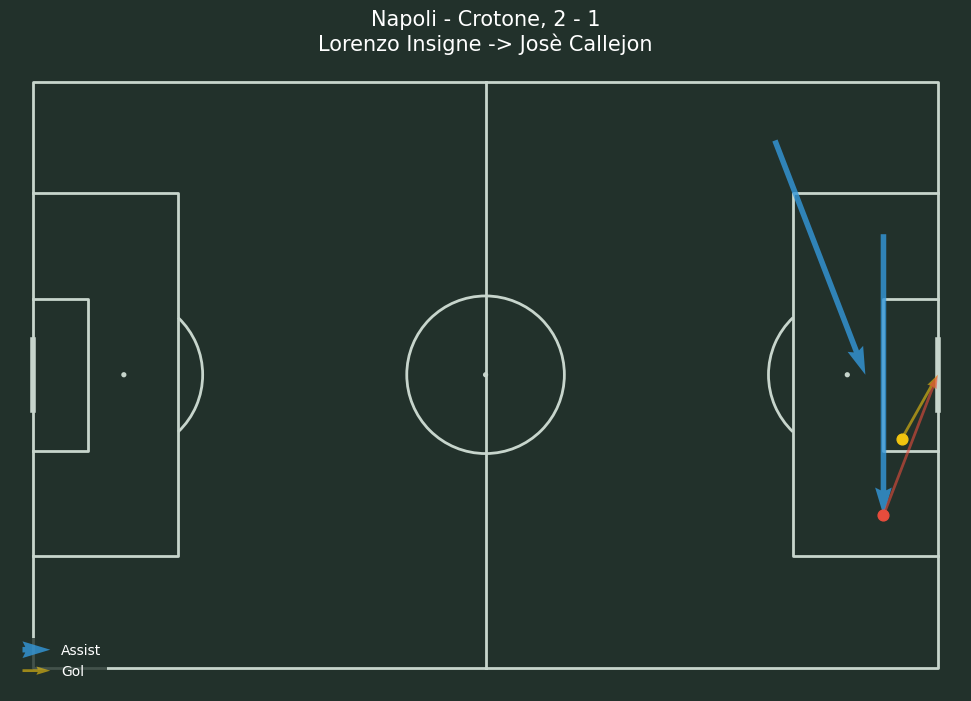

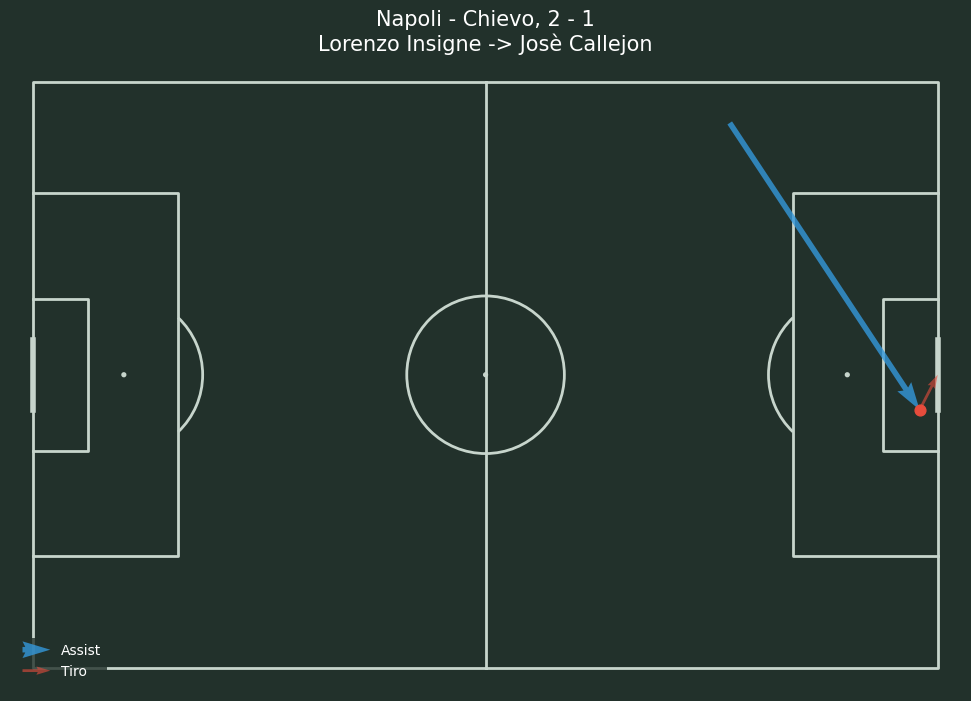

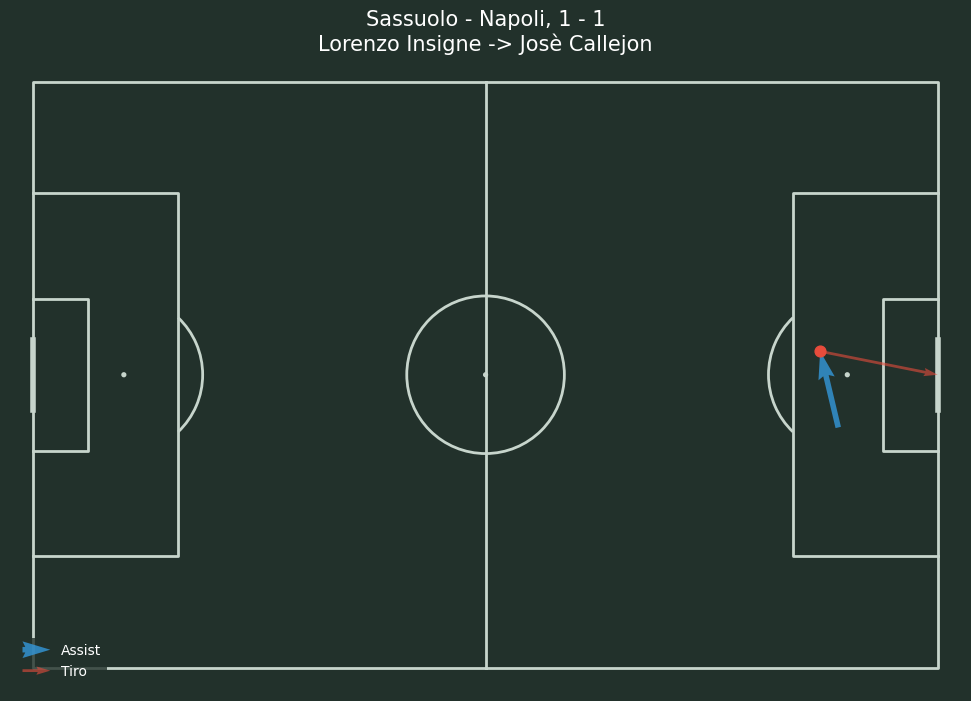

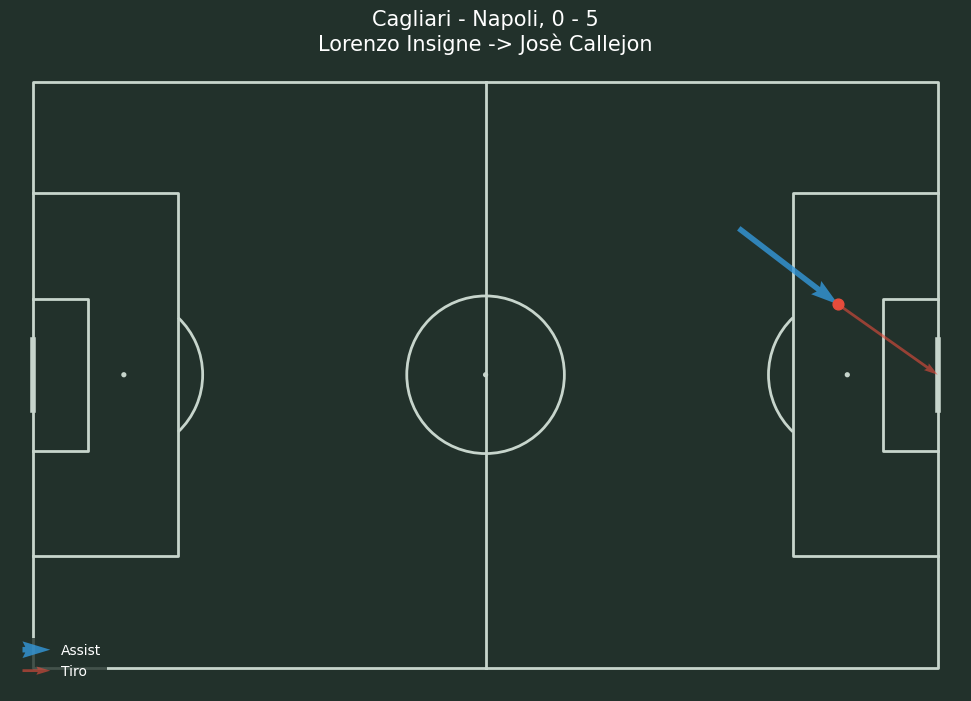

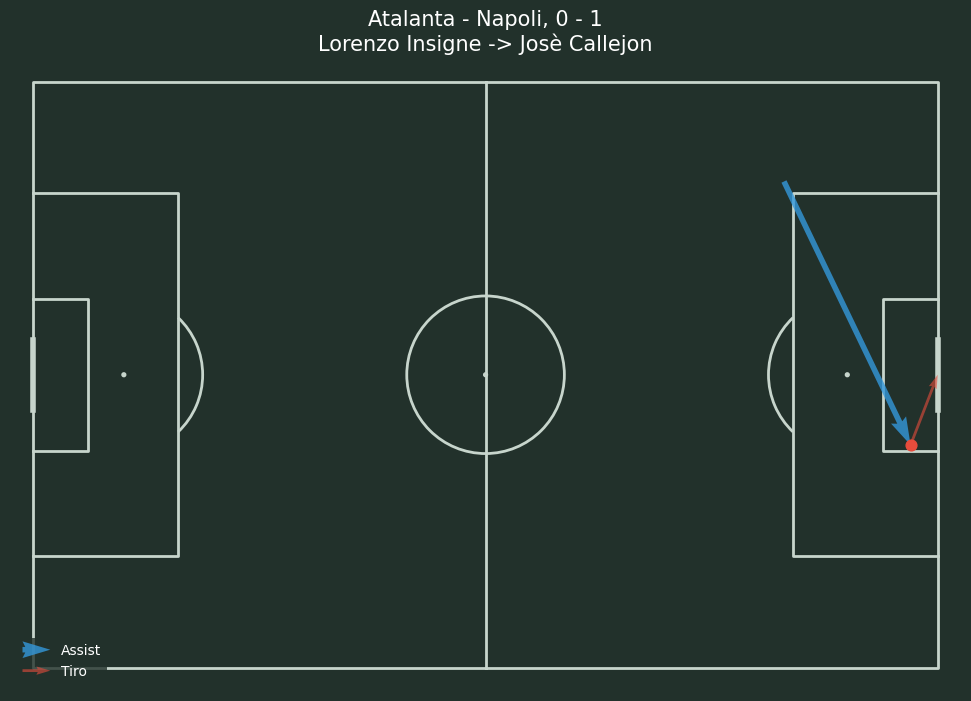

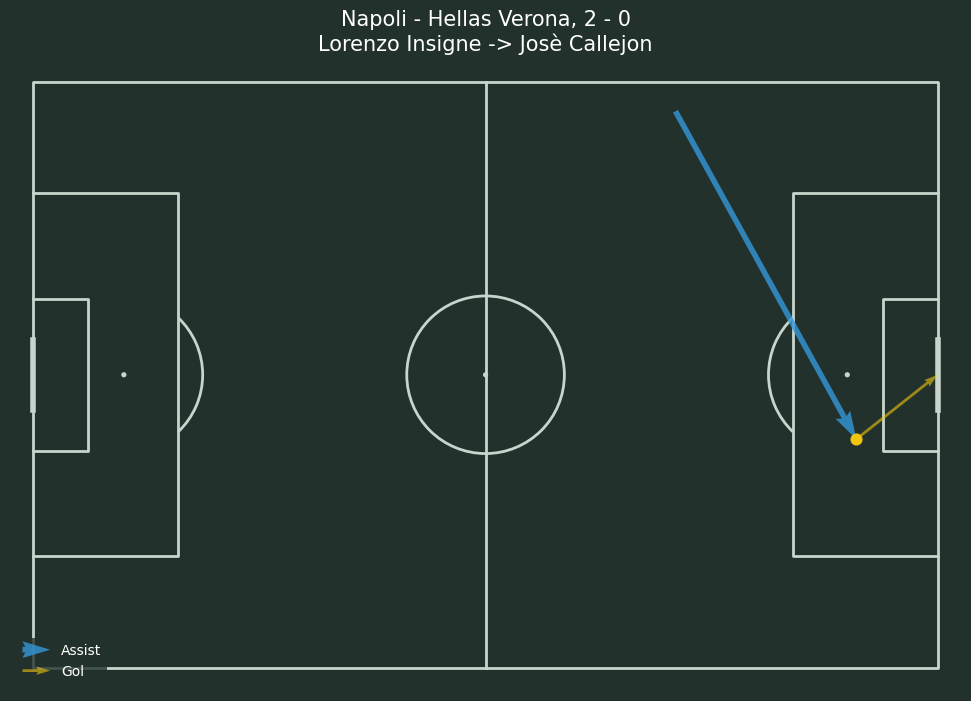

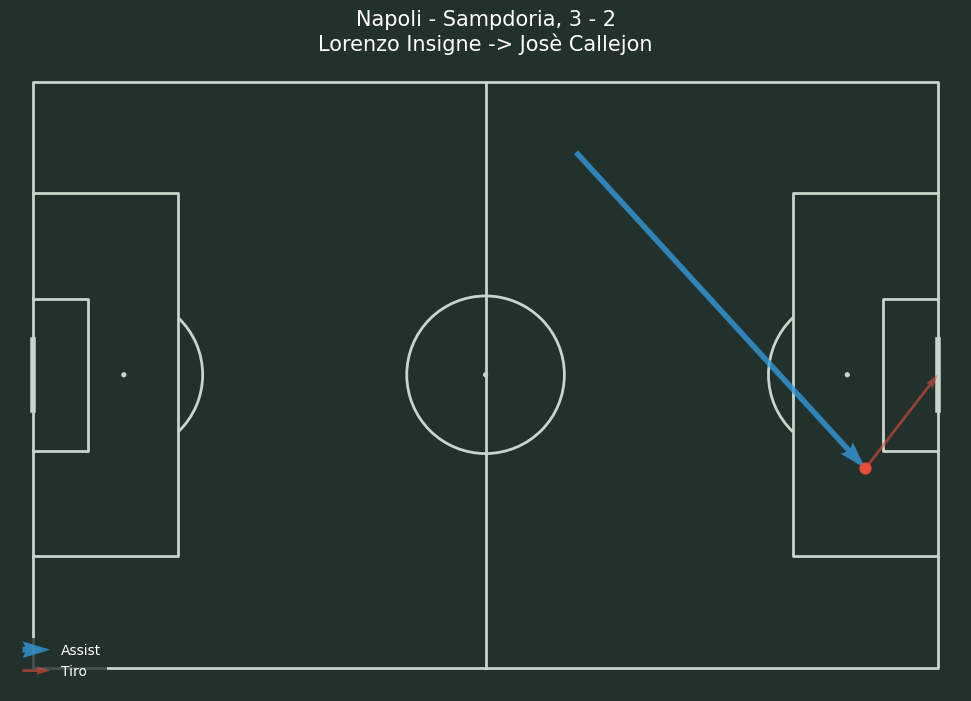

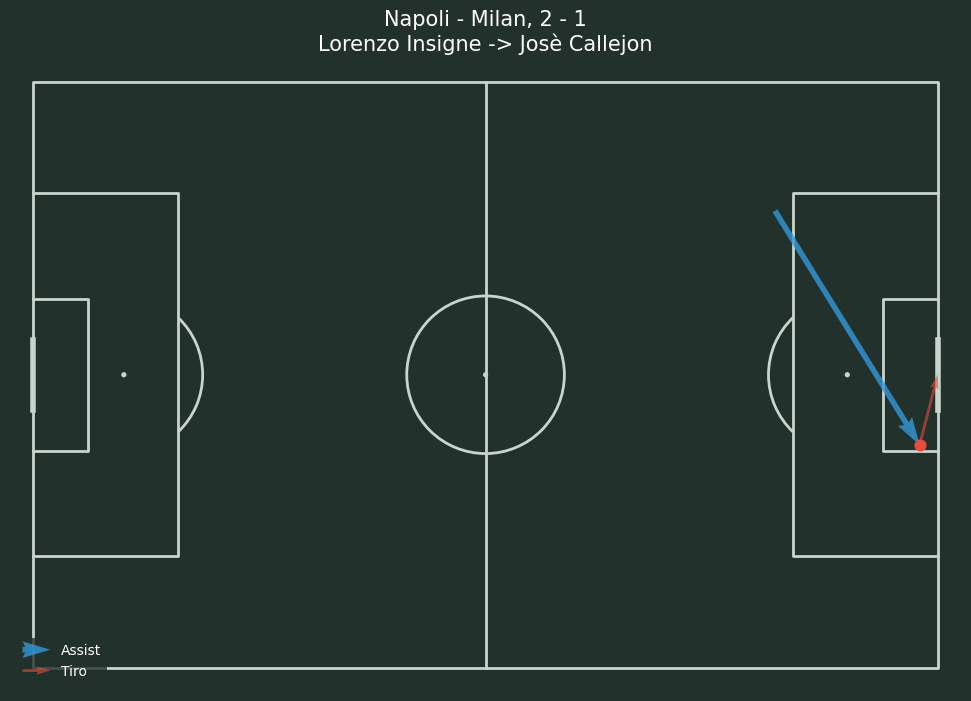

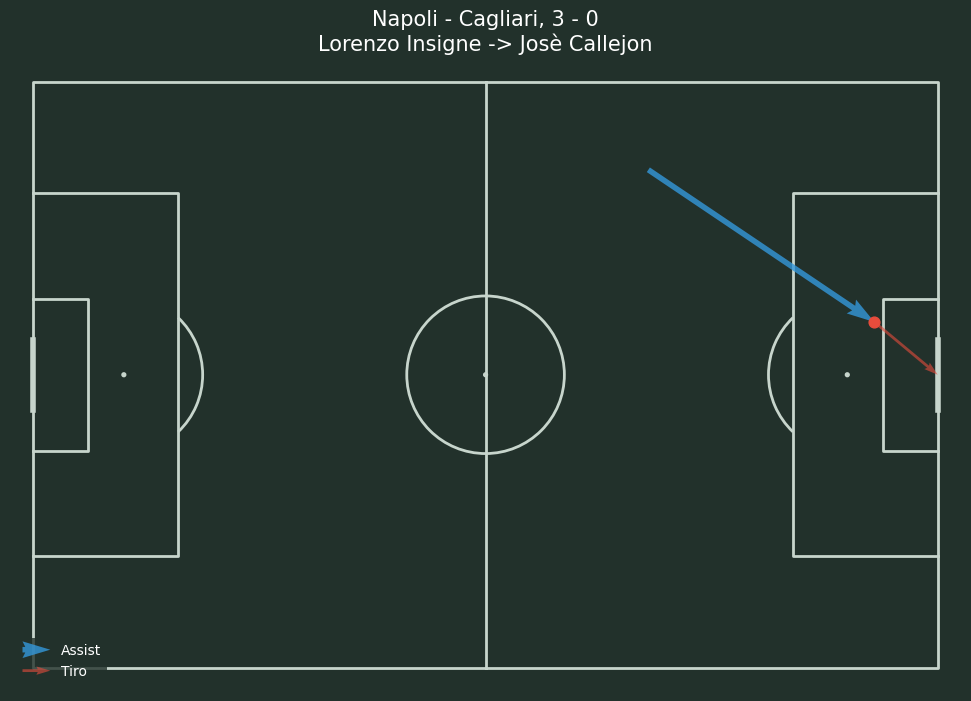

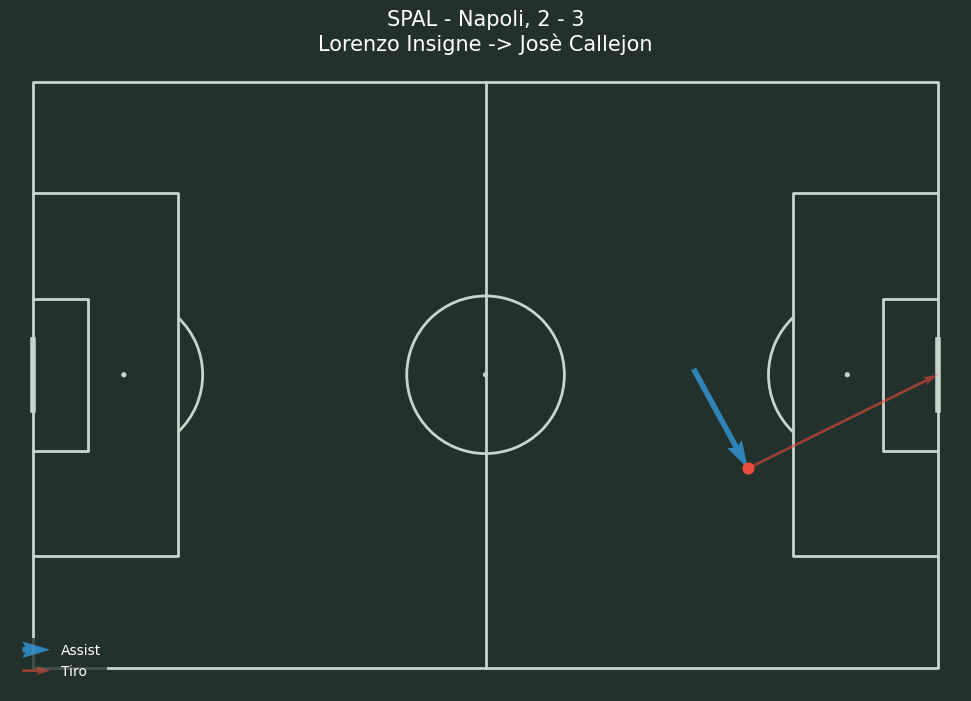

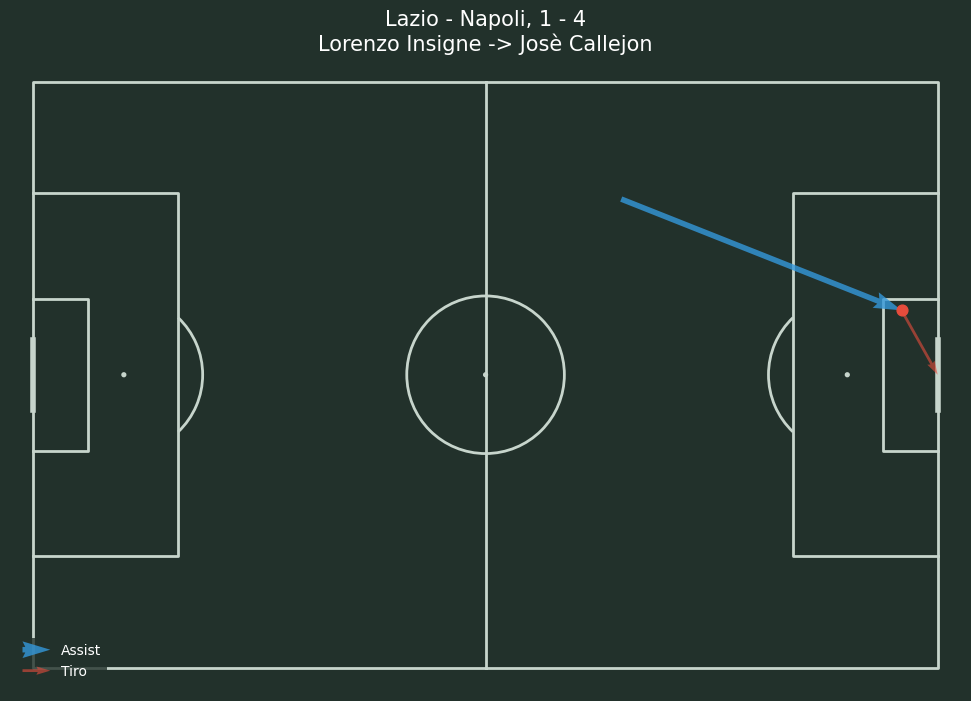

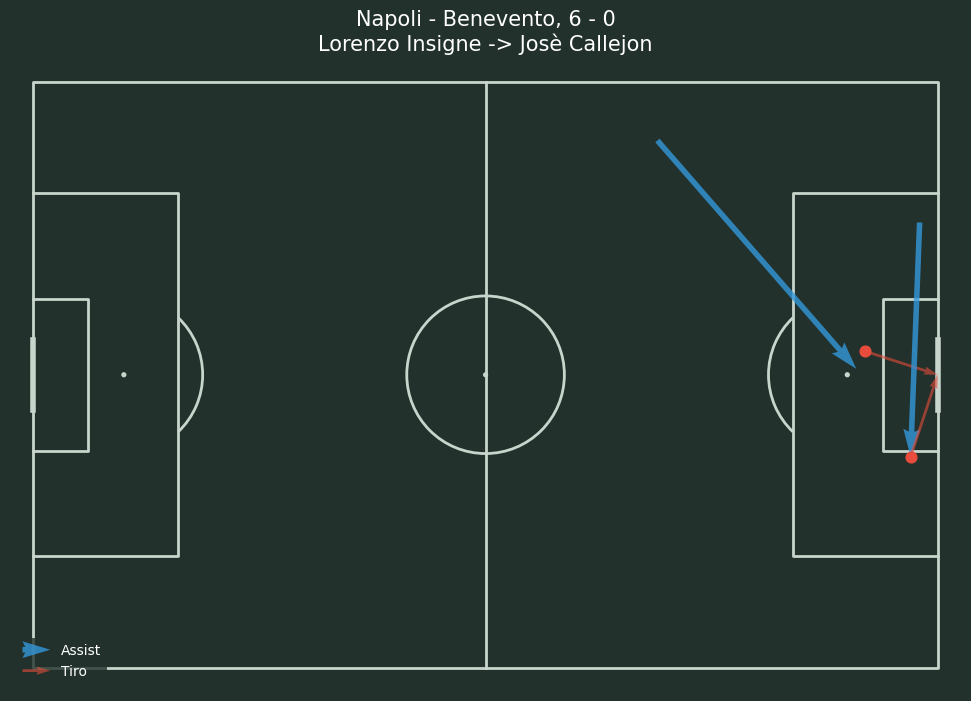

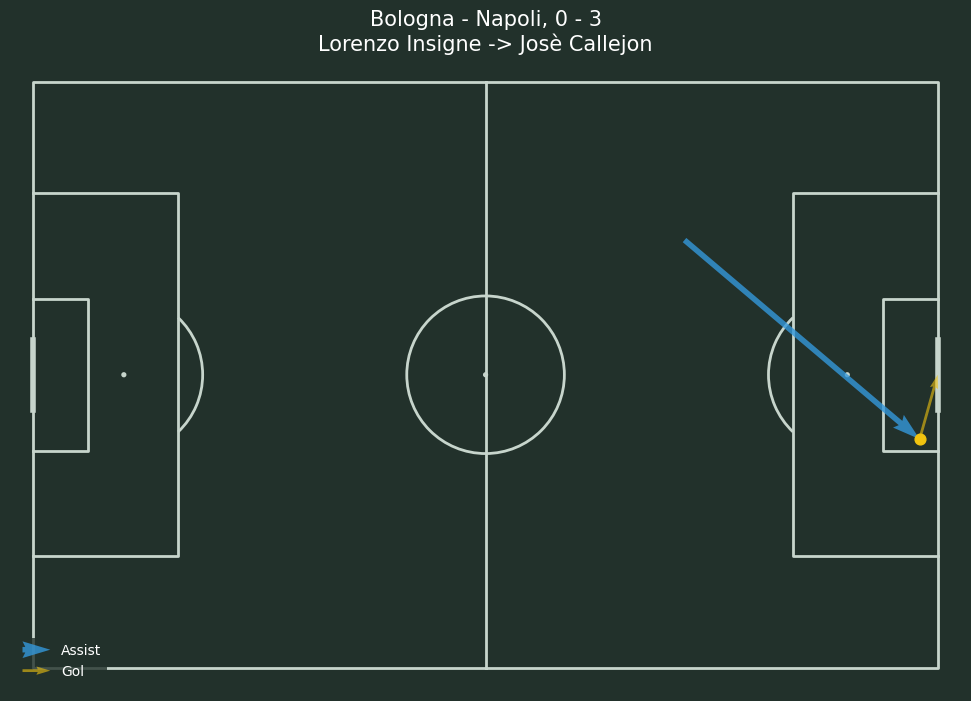

In [33]:
# ID dei giocatori (Insigne -> Callejon)
id_mittente = 21385  
id_destinatario = 3313 


for m_id in napoli_matches:
    # Estrazione dati
    df_assist = get_assist_goal_df(df_events, id_mittente, id_destinatario, m_id)
    
    if not df_assist.empty:
        pitch = Pitch(pitch_type='wyscout', pitch_color='#22312b', line_color='#c7d5cc')
        fig, ax = pitch.draw(figsize=(10, 7))
        fig.set_facecolor('#22312b')

        # Iteriamo su ogni azione trovata (fondamentale per gestire più assist/gol)
        for i, row in df_assist.iterrows():
            # Disegniamo la freccia dell'assist (azzurra)
            # Usiamo label solo per il primo elemento per non sporcare la legenda
            l_assist = 'Assist' if i == 0 else ""
            pitch.arrows(row['x_start'], row['y_start'], row['x_end'], row['y_end'], 
                         color="#3498db", width=4, ax=ax, label=l_assist, alpha=0.8)
            
            # Decidiamo il colore del tiro riga per riga
            color_tiro = "#f1c40f" if row['is_goal'] else "#e74c3c"
            l_tiro = ('Gol' if row['is_goal'] else 'Tiro') if i == 0 else ""
            
            # Disegniamo la freccia del tiro verso la porta (100, 50)
            pitch.arrows(row['shot_x'], row['shot_y'], 100, 50, 
                         color=color_tiro, width=2, ax=ax, alpha=0.6, 
                         linestyle='--', label=l_tiro)
            
            # Aggiungiamo un punto nel punto di impatto del tiro
            pitch.scatter(row['shot_x'], row['shot_y'], color=color_tiro, s=60, ax=ax, zorder=3)

        match_label = next((m['label'] for m in matches if m['wyId'] == m_id), str(m_id))

        name_m = get_player_name(id_mittente)
        name_d = get_player_name(id_destinatario)
        #plt.title(f"{match_label}\n{name_m} -> {name_d}", color='white', fontsize=15)
        plt.title(f"{match_label}\n{name_m} -> José Callejón", color='white', fontsize=15)
        
        ax.legend(facecolor='#22312b', edgecolor='None', fontsize=10, loc='lower left', labelcolor='white')
        plt.show()

Analisi stagionale in corso per 38 partite...


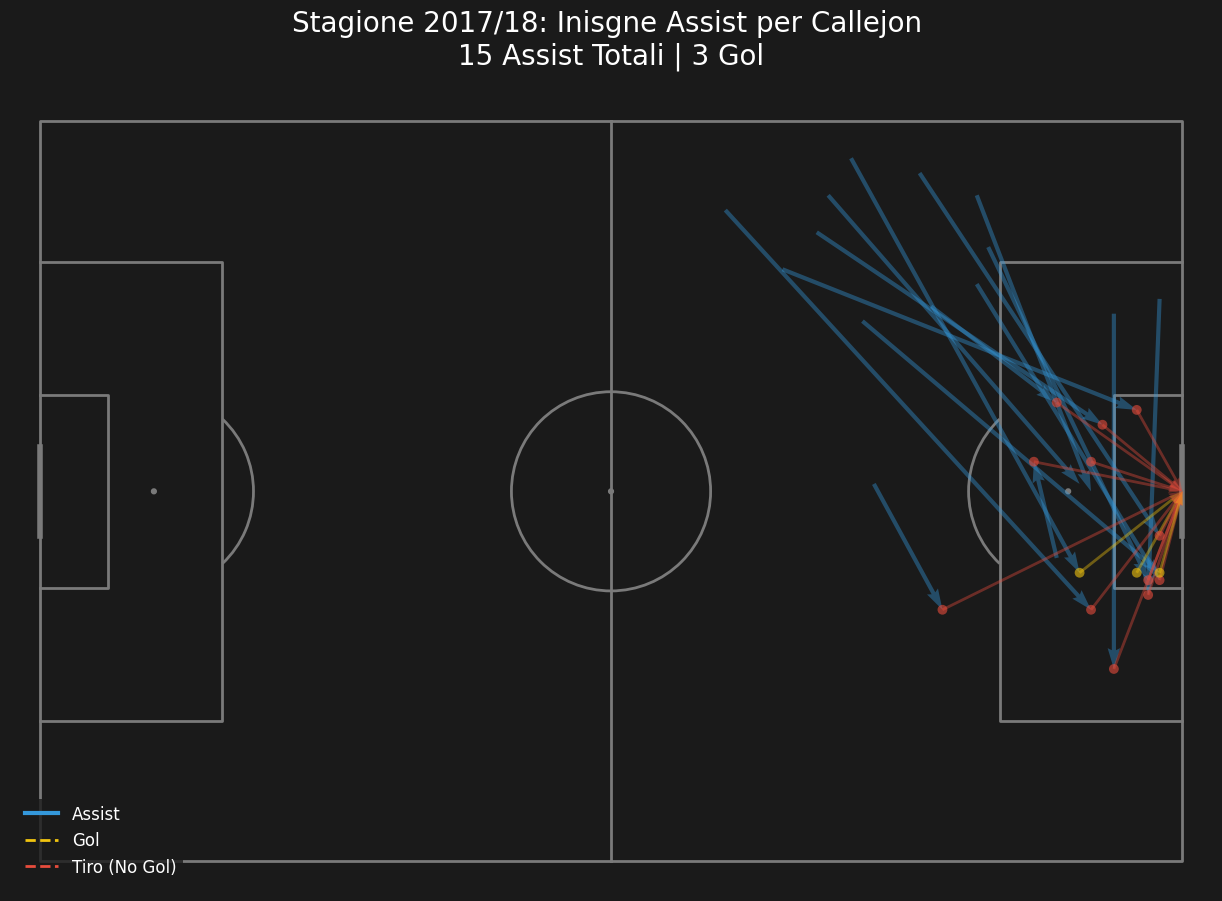

In [27]:
from matplotlib.lines import Line2D

# ACCUMULO DATI
all_assists_list = []
print(f"Analisi stagionale in corso per {len(napoli_matches)} partite...")

for m_id in napoli_matches:
    # Utilizza la funzione get_assist_goal_df definita in precedenza
    df_temp = get_assist_goal_df(df_events, id_mittente, id_destinatario, m_id)
    if not df_temp.empty:
        all_assists_list.append(df_temp)

if all_assists_list:
    df_all_season = pd.concat(all_assists_list, ignore_index=True)
    
    # CREAZIONE DEL SUPER PLOT
    pitch = Pitch(pitch_type='wyscout', pitch_color='#1a1a1a', line_color='#7a7a7a')
    fig, ax = pitch.draw(figsize=(13, 9))
    fig.set_facecolor('#1a1a1a')

    # DISEGNO DEGLI ASSIST
    pitch.arrows(df_all_season.x_start, df_all_season.y_start, 
                 df_all_season.x_end, df_all_season.y_end, 
                 color="#3498db", width=3, ax=ax, alpha=0.4, label='Assist')

    # DISEGNO DEI TIRI (Ciclo riga per riga per gestire il colore)
    for i, row in df_all_season.iterrows():
        color_tiro = "#f1c40f" if row['is_goal'] else "#e74c3c"
        
        # Disegniamo la freccia del tiro verso il centro della porta
        pitch.arrows(row['shot_x'], row['shot_y'], 100, 50, 
                     color=color_tiro, width=2, ax=ax, alpha=0.4, 
                     linestyle='--', zorder=2)
        
        # Punto nel punto esatto del tiro
        pitch.scatter(row['shot_x'], row['shot_y'], color=color_tiro, 
                      s=50, ax=ax, zorder=3, alpha=0.6, edgecolors='none')

    # tITOLO E LEGENDA
    name_m = get_player_name(id_mittente)
    name_d = get_player_name(id_destinatario)
    tot_gol = df_all_season['is_goal'].sum()

    #Funzione generale scrivo io il nome perchè altrimenti d
    #plt.title(f"Stagione 2017/18: {name_m} Assist per {name_d}\n{len(df_all_season)} Assist Totali | {tot_gol} Gol", 
     #         color='white', fontsize=20, pad=20)
    plt.title(f"Stagione 2017/18: Inisgne Assist per Callejon \n{len(df_all_season)} Assist Totali | {tot_gol} Gol", 
              color='white', fontsize=20, pad=20)
        
    # Legenda manuale corretta
    custom_lines = [Line2D([0], [0], color='#3498db', lw=3),
                    Line2D([0], [0], color='#f1c40f', lw=2, ls='--'),
                    Line2D([0], [0], color='#e74c3c', lw=2, ls='--')]
    
    ax.legend(custom_lines, ['Assist', 'Gol', 'Tiro (No Gol)'], 
              facecolor='#1a1a1a', edgecolor='None', fontsize=12, loc='lower left', labelcolor='white')
    
    plt.show()
else:
    print("Nessun assist trovato per questa coppia in tutta la stagione.")